In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


In [ ]:
## Setup
#We use pandas and NumPy for cleaning/analysis, and Matplotlib for plotting. Display settings are adjusted so dataframe outputs are readable in the notebook.

In [2]:
DATA_PATH = "data/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(DATA_PATH)

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
## Load the dataset
#The dataset is loaded from a local `data/` folder using a relative path for portability. We display the first few rows to confirm successful loading and check column names.


In [3]:
df.shape, df.columns

((5110, 12),
 Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type',
        'avg_glucose_level', 'bmi', 'smoking_status', 'stroke'],
       dtype='object'))

In [4]:
df.info()
df.isna().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


bmi                  201
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
smoking_status         0
stroke                 0
dtype: int64

In [ ]:
## Data cleaning decisions
#- Remove rows where **bmi** is missing (required for BMI analysis).
#- Ensure key binary columns are numeric: **hypertension**, **stroke** (0/1).
#- Drop duplicate rows if present.


In [5]:
# Drop duplicates (safe default)
df = df.drop_duplicates().copy()

# Coerce key columns to numeric (in case of weird types)
for col in ["hypertension", "stroke"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows missing essential fields for THIS analysis
df_clean = df.dropna(subset=["bmi", "hypertension", "stroke"]).copy()

df_clean.shape


(4909, 12)

In [ ]:
## Cleaning approach
#- Duplicates are removed to avoid inflating counts and rates.
#- `hypertension` and `stroke` are forced to numeric values to ensure valid group comparisons.
#- Rows missing key fields (`bmi`, `hypertension`, `stroke`) are removed because they cannot contribute to the analysis.


In [6]:
df_clean[["hypertension", "stroke"]].value_counts(dropna=False).head(10)
df_clean["bmi"].describe()


count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

In [7]:
# BMI categories (standard-ish)
bmi_bins = [0, 18.5, 25, 30, np.inf]
bmi_labels = ["Underweight", "Normal", "Overweight", "Obese"]

df_clean["bmi_group"] = pd.cut(df_clean["bmi"], bins=bmi_bins, labels=bmi_labels, right=False)

df_clean["bmi_group"].value_counts(dropna=False)
## BMI categorisation
#BMI is continuous, so we bin it into standard clinical categories. This makes group comparisons clearer and easier to interpret than comparing raw BMI values.


bmi_group
Obese          1920
Overweight     1409
Normal         1243
Underweight     337
Name: count, dtype: int64

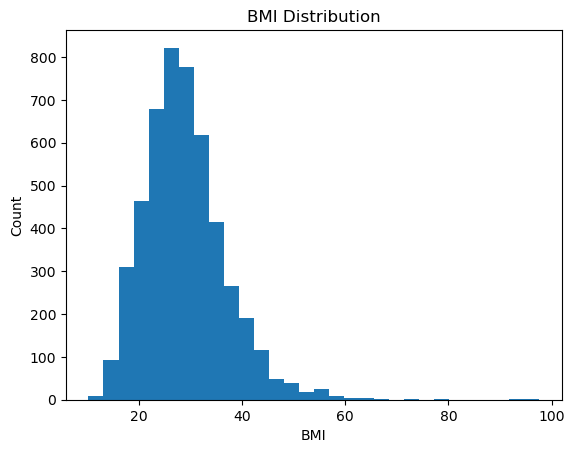

In [8]:
df_clean["bmi"].plot(kind="hist", bins=30)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()


In [9]:
bmi_hyper_rate = df_clean.groupby("bmi_group")["hypertension"].mean().sort_values(ascending=False)
bmi_hyper_rate


/var/folders/_n/cnp026fx2tj9qpnp8fw6c5840000gn/T/ipykernel_38065/1317994923.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_hyper_rate = df_clean.groupby("bmi_group")["hypertension"].mean().sort_values(ascending=False)


bmi_group
Obese          0.143750
Overweight     0.083747
Normal         0.044248
Underweight    0.005935
Name: hypertension, dtype: float64

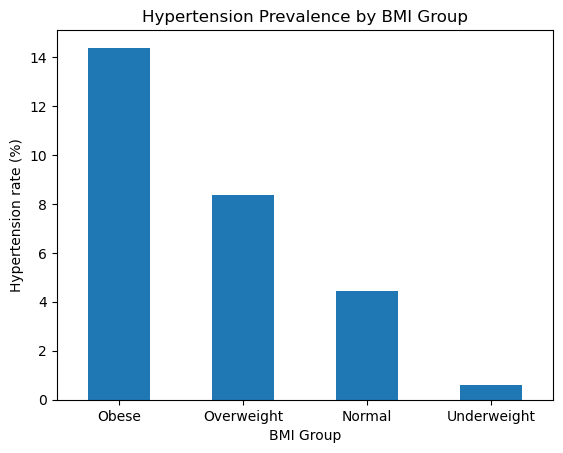

In [10]:
(bmi_hyper_rate * 100).plot(kind="bar")
plt.title("Hypertension Prevalence by BMI Group")
plt.ylabel("Hypertension rate (%)")
plt.xlabel("BMI Group")
plt.xticks(rotation=0)
plt.show()


In [ ]:
### Interpretation
#Hypertension prevalence increases across BMI categories in this dataset.  
#This suggests BMI may be a meaningful risk factor associated with hypertension.


In [11]:
stroke_rate_by_hyper = df_clean.groupby("hypertension")["stroke"].mean()
stroke_rate_by_hyper


hypertension
0    0.033423
1    0.133038
Name: stroke, dtype: float64

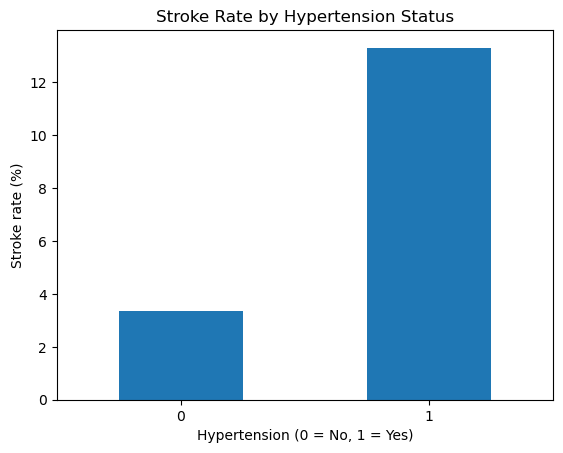

In [12]:
(stroke_rate_by_hyper * 100).plot(kind="bar")
plt.title("Stroke Rate by Hypertension Status")
plt.ylabel("Stroke rate (%)")
plt.xlabel("Hypertension (0 = No, 1 = Yes)")
plt.xticks(rotation=0)
plt.show()


In [13]:
ct = pd.crosstab(df_clean["hypertension"], df_clean["stroke"], normalize="index") * 100
ct


stroke,0,1
hypertension,,
0,96.657694,3.342306
1,86.696231,13.303769


In [ ]:
## Contingency table (percentages)
# A crosstab provides a clear percentage breakdown of stroke occurrence within each hypertension group, which helps interpret group differences beyond raw counts.


In [ ]:
### Interpretation
#The stroke rate differs between hypertension groups, suggesting an association between hypertension and stroke occurrence in this dataset.  
#This is descriptive (EDA) and does not prove causation.


In [ ]:
## Key Insights
#- Hypertension prevalence increases across BMI categories in this dataset.
#- Stroke rate is higher in the hypertension group compared to the non-hypertension group.
#- These findings are descriptive and depend on dataset quality and sampling.


In [ ]:
## Limitations
#- Dataset may not be representative of the general population.
#- Missing BMI values required row removal, which could bias results.
#- EDA shows association, not causation.

## Next Steps
#- Explore other risk factors (age, glucose level, smoking status).
#- Check for confounding (e.g., age vs hypertension vs stroke).
#- Optional: build a baseline predictive model.
